## Import library framework

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Read database

In [52]:
pd.set_option('display.max_columns', None)
df = pd.read_csv("../../Database/SuperStoreOrders - SuperStoreOrders.csv")
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.1400,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.0360,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.6400,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.0550,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.7700,4.70,Medium,2011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,31/12/2014,4/1/2015,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",14,2,0.2,4.5188,0.89,Medium,2014
51286,MO-2014-2560,31/12/2014,5/1/2015,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",4,1,0.0,0.4200,0.49,Medium,2014
51287,MX-2014-110527,31/12/2014,2/1/2015,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",26,3,0.0,12.3600,0.35,Medium,2014
51288,MX-2014-114783,31/12/2014,6/1/2015,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",7,1,0.0,0.5600,0.20,Medium,2014


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [54]:
# Check missing values
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

## Feature Engineering

In [55]:
# Clean data for datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')

In [56]:
# Convert sales and ensure profit are numeric
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['sales'] = round(df['sales'], 2)
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [57]:
# Add column unit price feature (sales divided by quantity)
df['unit_price'] = df['sales'] / df['quantity'] # TODO: To know about unit price for each product
df['unit_price'] = round(df['unit_price'], 2)

# Add column profit margin feature (profit divided by sales)
df['profit_margin'] = df['profit'] / df['sales'] # TODO: To know about profit margin for each product
df['profit_margin'] = round(df['profit_margin'], 2)

In [58]:
# Group sales, profit, unit_price, and profit_margin into 1 group
sales_trend = ['sales', 'profit', 'unit_price', 'profit_margin', 'shipping_cost']
def sales_trend_enchance(sales_trend):
    # for sales_trend * 10000 to make it more visible
    df[sales_trend] = df[sales_trend] * 10000
    return df

sales_trend_enchance(sales_trend)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,2600.0
1,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,3000.0
2,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,4500.0
3,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,48200.0,High,2011,150000.0,-5800.0
4,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",1140000.0,5,0.1,377700.0,47000.0,Medium,2011,228000.0,3300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,NaT,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",140000.0,2,0.2,45188.0,8900.0,Medium,2014,70000.0,3200.0
51286,MO-2014-2560,NaT,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",40000.0,1,0.0,4200.0,4900.0,Medium,2014,40000.0,1000.0
51287,MX-2014-110527,NaT,2015-02-01,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,OFF-LA-10004182,Office Supplies,Labels,"Hon Color Coded Labels, 5000 Label Set",260000.0,3,0.0,123600.0,3500.0,Medium,2014,86700.0,4800.0
51288,MX-2014-114783,NaT,2015-06-01,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,OFF-LA-10000413,Office Supplies,Labels,"Hon Legal Exhibit Labels, Alphabetical",70000.0,1,0.0,5600.0,2000.0,Medium,2014,70000.0,800.0


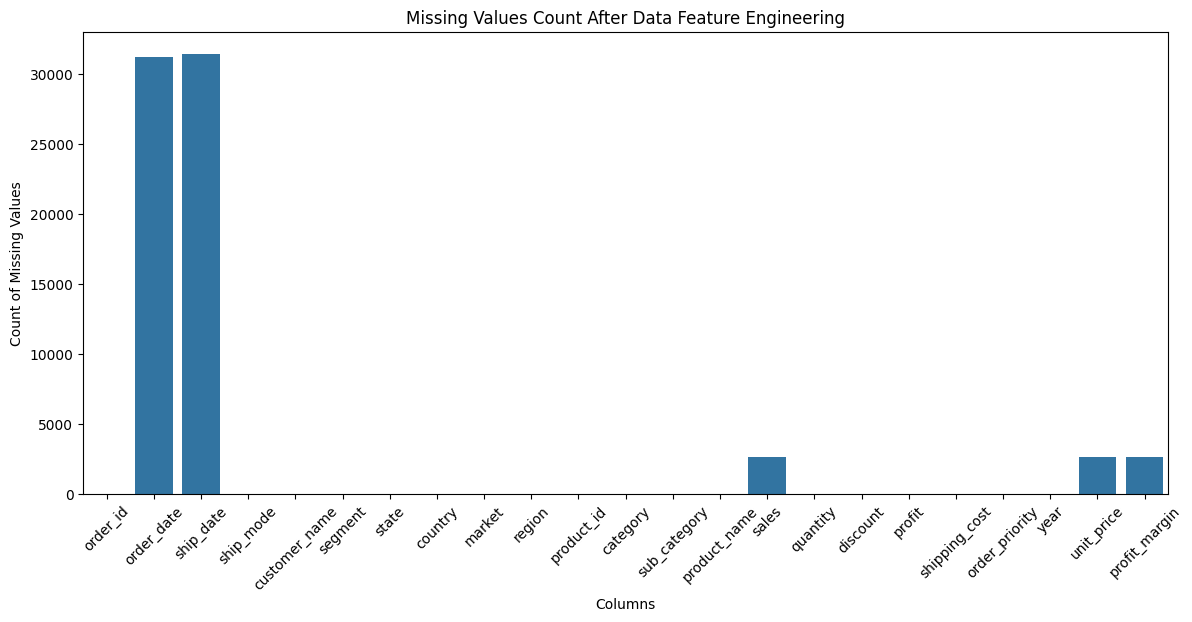

In [59]:
# Check missing values after data feature engineering
# ---- IGNORE ---
# Visualize missing values data after data feature engineering
plt.figure(figsize=(14, 6))
sns.barplot(x=df.isnull().sum().index, y=df.isnull().sum().values)
plt.title('Missing Values Count After Data Feature Engineering')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.show()

In [60]:
# Handle missing values

# Imputation methods on sales, unit_price, and profit_margin columns
# 1. Impute with mean
mean_imputed_sales = df['sales'].fillna(df['sales'].mean())
mean_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].mean())
mean_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].mean())

# 2. Impute with median
median_imputed_sales = df['sales'].fillna(df['sales'].median())
median_imputed_unit_price = df['unit_price'].fillna(df['unit_price'].median())
median_imputed_profit_margin = df['profit_margin'].fillna(df['profit_margin'].median())

# 3. Interpolate missing values with linear method
linear_interpolated_sales = df['sales'].interpolate(method='linear')
linear_interpolated_unit_price = df['unit_price'].interpolate(method='linear')
linear_interpolated_profit_margin = df['profit_margin'].interpolate(method='linear')

In [61]:
# Handle missing values for sales, unit_price, and profit_margin columns using linear interpolation
df['sales'] = linear_interpolated_sales
df['unit_price'] = linear_interpolated_unit_price
df['profit_margin'] = linear_interpolated_profit_margin

In [62]:
# Handle missing values for order_date and ship_date columns using forward fill method
df['order_date'] = df['order_date'].ffill()
df['ship_date'] = df['ship_date'].ffill()
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
unit_price        0
profit_margin     0
dtype: int64

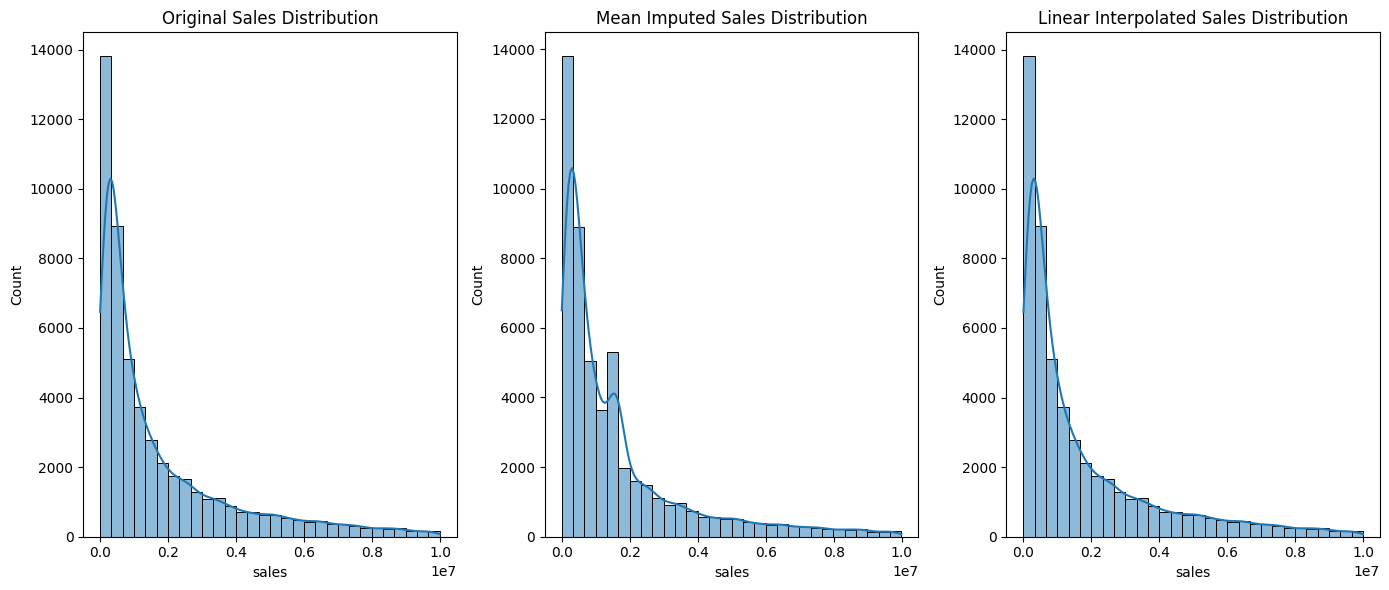

In [63]:
# visualize comparison of original sales, mean imputed sales, and linear interpolated sales
plt.figure(figsize=(14, 6))
plt.subplot(1, 3, 1)
sns.histplot(df['sales'], bins=30, kde=True)
plt.title('Original Sales Distribution')
plt.subplot(1, 3, 2)
sns.histplot(mean_imputed_sales, bins=30, kde=True)
plt.title('Mean Imputed Sales Distribution')
plt.subplot(1, 3, 3)
sns.histplot(linear_interpolated_sales, bins=30, kde=True)
plt.title('Linear Interpolated Sales Distribution')
plt.tight_layout()
plt.show()

## Data Visualization

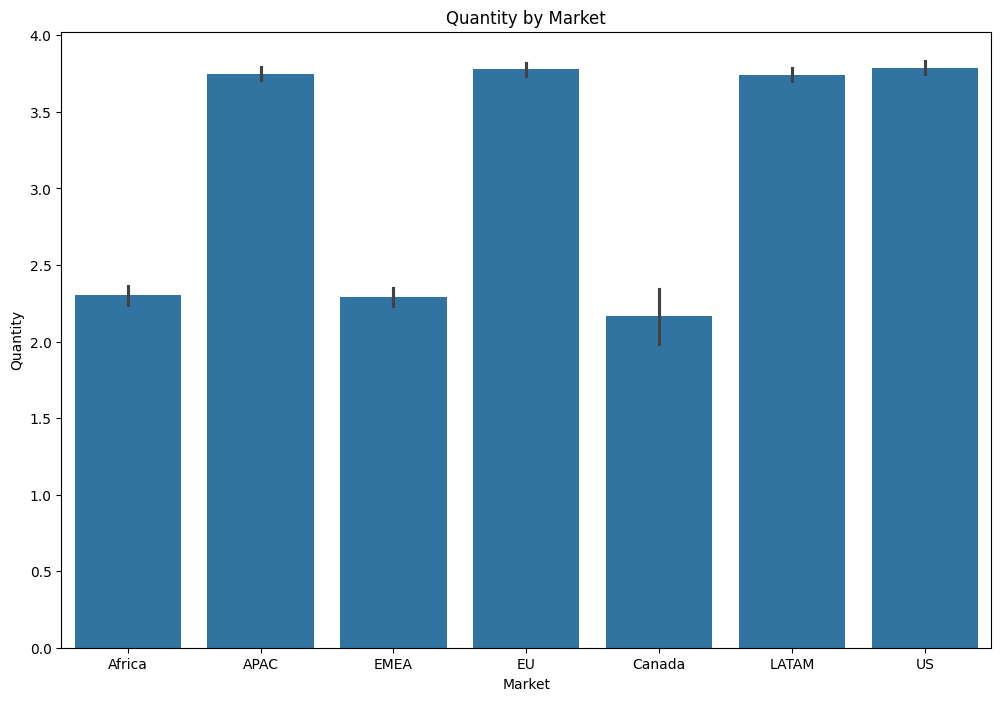

In [64]:
# Visual data for sales by category
plt.figure(figsize=(12, 8))
sns.barplot(x='market', y='quantity', data=df)
plt.title('Quantity by Market')
plt.xlabel('Market')
plt.ylabel('Quantity')
plt.show()

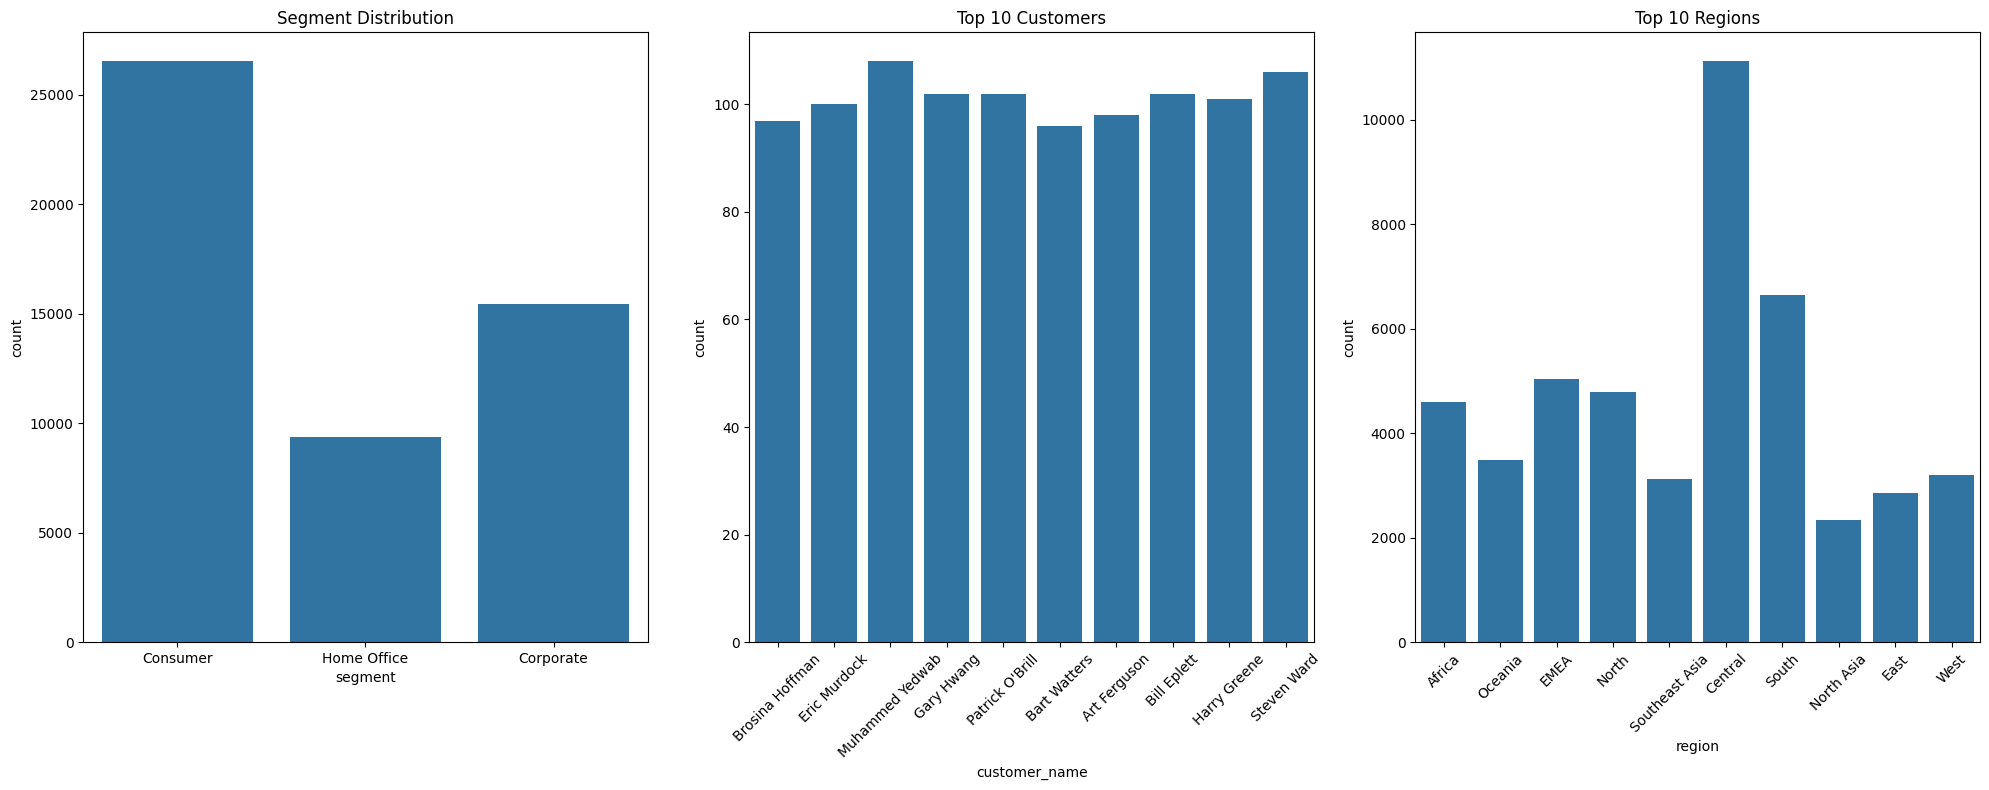

In [65]:
# Get top 10 customer_name (most frequent)
top_customers_10 = df['customer_name'].value_counts().head(10)

# Get top 10 regions (most frequent)
top_regions_10 = df['region'].value_counts().head(10)

# Data visualization for segment (user), customer_name (top 10), and region (top 10)
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
sns.countplot(x='segment', data=df, ax=axes[0])
sns.countplot(x='customer_name', data=df[df['customer_name'].isin(top_customers_10.index)], ax=axes[1])
sns.countplot(x='region', data=df[df['region'].isin(top_regions_10.index)], ax=axes[2])

axes[0].set_title('Segment Distribution')
axes[1].set_title('Top 10 Customers')
axes[1].tick_params(axis='x', rotation=45)
axes[2].set_title('Top 10 Regions')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

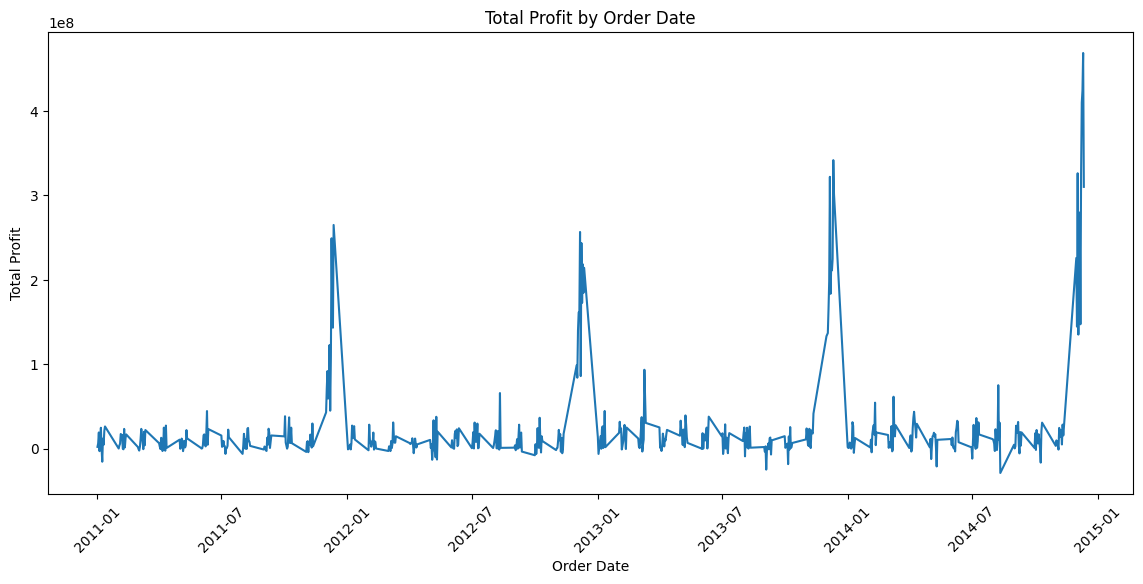

In [66]:
# Total profit by order_date
profit_by_date = df.groupby('order_date')['profit'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(profit_by_date['order_date'], profit_by_date['profit'])
plt.title('Total Profit by Order Date')
plt.xlabel('Order Date')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.show()

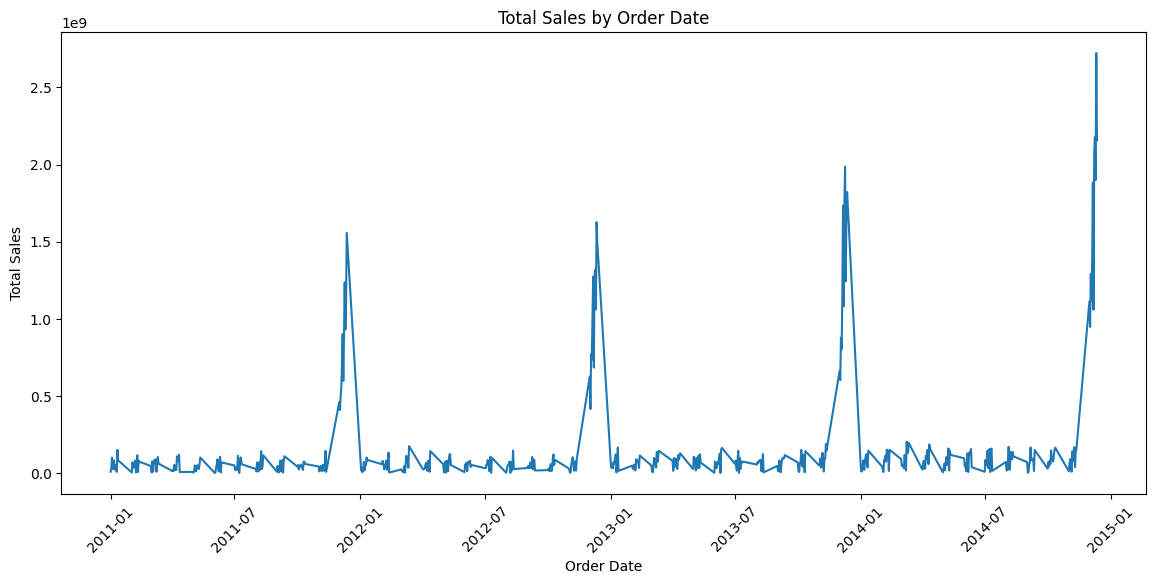

In [67]:
# Total sales by order_date
sales_by_date = df.groupby('order_date')['sales'].sum().reset_index()
plt.figure(figsize=(14, 6))
plt.plot(sales_by_date['order_date'], sales_by_date['sales'])
plt.title('Total Sales by Order Date')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           51290 non-null  float64       
 15  qu

## Data encoding - Data scale

In [69]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Copy data
df_clean = df.copy()

# Remove data isn't needed for machine learning algorithm
df_clean.drop(columns=['order_id', 'order_date', 'ship_date', 'product_id'], inplace=True)
df_clean.head()

# Encode data for categorical features
label_encoder = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = label_encoder.fit_transform(df_clean[col])

# Show data
df_clean.head()

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,3,751,0,255,2,1,0,1,14,3413,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,2600.0
1,3,398,0,702,6,0,9,1,15,168,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,3000.0
2,2,48,0,175,56,3,5,1,14,3382,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,4500.0
3,2,275,2,939,123,4,7,1,12,1330,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-5800.0
4,3,398,0,702,6,0,9,0,9,1228,1140000.0,5,0.1,377700.0,47000.0,3,2011,228000.0,3300.0


## Divide data into X and y

In [78]:
# Define features and target variable
X = df_clean.drop(columns=['sales'])
y = df_clean['sales']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (41032, 18)
X_test shape: (10258, 18)
y_train shape: (41032,)
y_test shape: (10258,)


In [71]:
df_clean.describe()

,ship_mode,customer_name,segment,state,country,market,region,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,5.129000e+04,51290.000000,51290.000000,5.129000e+04,5.129000e+04,51290.000000,51290.000000,5.129000e+04,5.129000e+04
mean,2.254709,398.191870,0.665139,561.357692,79.073738,3.351063,6.052388,1.005167,7.497446,1877.063755,1.740327e+06,3.476545,0.142908,2.864174e+05,2.637592e+05,2.118308,2012.777208,5.971352e+05,-inf
std,1.083110,229.209363,0.766199,304.187398,46.684209,2.219025,3.587991,0.624701,4.844664,1090.949227,2.090926e+06,2.278766,0.212280,1.744241e+06,5.729680e+05,1.081088,1.098931,7.884276e+05,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000,0.000000,-6.599978e+07,0.000000e+00,0.000000,2011.000000,0.000000e+00,-inf
25%,2.000000,199.000000,0.000000,311.000000,44.000000,1.000000,3.000000,1.000000,3.000000,882.000000,3.100000e+05,2.000000,0.000000,0.000000e+00,2.610000e+04,1.000000,2012.000000,1.200000e+05,0.000000e+00
50%,3.000000,399.000000,0.000000,572.000000,81.000000,4.000000,6.000000,1.000000,7.000000,1862.000000,8.500000e+05,3.000000,0.000000,9.240000e+04,7.790000e+04,3.000000,2013.000000,2.900000e+05,1.629167e+03
75%,3.000000,597.000000,1.000000,820.000000,134.000000,5.000000,10.000000,1.000000,12.000000,2904.000000,2.400000e+06,5.000000,0.200000,3.681000e+05,2.445000e+05,3.000000,2014.000000,7.450000e+05,3.300000e+03
max,3.000000,794.000000,2.000000,1093.000000,146.000000,6.000000,12.000000,2.000000,16.000000,3787.000000,9.990000e+06,14.000000,0.850000,8.399976e+07,9.335700e+06,3.000000,2014.000000,9.250000e+06,5.800000e+03


In [77]:
numeric_cols = df_clean.select_dtypes(include=np.number)
print(np.isin(numeric_cols).sum())

TypeError: isin() missing 1 required positional argument: 'test_elements'

# Data scaling

In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_clean.drop(columns=['sales']))
scaled_df = pd.DataFrame(scaled_features, columns=df_clean.drop(columns=['sales']).columns)

ValueError: Input X contains infinity or a value too large for dtype('float64').

## Machine learning - Supervised learning to predict Sales, Profit, Risk management company

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

## Deep learning for prediction

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks